In [1]:
#Version controll: 
#last change 14.05.2025

# MFA rye straw cascading treatment system

This model presents a cascading treatment system for rye straw. After rye harvest, the straw is used for biogas production. The resulting by-products are further processed to produce mycelium-based composites (MBC), biodegradable materials that can substitute various synthetic products made from petroleum. Dynamic stock modelling is applied in the MBC use phase to account for different lifetimes of MBC products. From the MBC EoL-Treatment, biochar is obtained as a soil enhancement product. The mineralization process of the biochar in the litosphere is calculatated via a first order modelling process. The data used for the model is based on a research biogas plant from the chair of circular economy and recycling technology, TU Berlin. For the dynamic model, an increase of input flows of 2% per year is assumed.

<img src="system_flow_diagram.svg" alt="system_flow_diagram">

## 0 Load packages

This cell imports all necessary packages. It also loads the ODYM framework and the bioDYM_addon, both are included as files in the project (see folder /framework). 

In [2]:
### Load packages ###

# Load general libraries
import sys, os
import numpy as np
import pandas as pd
from scipy.stats import lognorm
import xlsxwriter
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator,
                               FormatStrFormatter,
                               AutoMinorLocator)
import warnings
import re
from collections import defaultdict
from scipy.optimize import minimize
import copy

# Load ODYM package
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),'framework', 'ODYM-master_20241127', 'odym', 'modules')) 

# Import the ODYM class file
import ODYM_Classes as msc 
# Import the ODYM function file
import ODYM_Functions as msf
# Import the dynamic stock model library
import dynamic_stock_model as dsm 


# Load bioDYM_addon
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'framework', 'bioDYM_add-on', 'modules')) 

# Import classes for first order model process
import bioDYM_classes as bicl
# Import plotting functions
import bioDYM_plotting as bipl
# Import export functions
import bioDYM_export as bix




# Enables plotting directly in the notebook (in most cases this is already enabled)
%matplotlib inline

## 1 Definition of system and relevant aspects

The system definition is quite rigid, all aspects of the model are defined. In this setup here, the model includes a time dimension and an element dimension. Elements can be materials or included substances. Here, the top level is simply called material and sub level elements are water content (WC), dry matter (DM) and carbon content (CC). To adapt this section, the first three cells can simply be copied and only the years of the analysis and the elements included have to be modified. Then, all processes, stocks and flows are defined. In this study, this is done building up on the input data table. It is also possible to do it in a more simple way by just defining processes, flows and stocks manually in the Notebook (see case_study_bachelor_thesis or basic_examples).

In general, processes are stored in the ProcessList, flows are stored in the FlowDict, stocks are stored in the StockDict and parameters (like TCs) are stored in the ParameterDict.

In [3]:
### Initiate model ###

# Create empty dictionary of model classifications
ModelClassification  = {}

# Define period of analysis and create list of years (you have to put end year + 1 here, in this example, analysis period is 2022 to 2036)
MyYears = list(np.arange(2025,2051)) 
# Classification for time labelled 'Time' must always be present, with Items containing a list of ordered integers representing years, months, or other discrete time intervals
ModelClassification['Time'] = msc.Classification(Name = 'Time', Dimension = 'Time', ID = 1,
                                                 Items = MyYears)

# Classification for elements labelled 'Element' must always be present, with Items containing a list of the symbols of the elements covered.
# Here, other elements (like nitrogen or phosphorus) could be added to the ODYM MFA system
ModelClassification['Element'] = msc.Classification(Name = 'Elements', Dimension = 'Element', 
                                                    ID = 2, Items = ['material', 'WC', 'DM', 'CC'])


# Get model time start, end, and duration:
Model_Time_Start = int(min(ModelClassification['Time'].Items))
Model_Time_End   = int(max(ModelClassification['Time'].Items))
Model_Duration   = Model_Time_End - Model_Time_Start


In [4]:
### Set up a table with all indices ###


IndexTable = pd.DataFrame({'Aspect'        : ['Time','Element'], # 'Time' and 'Element' must be present!
                           'Description'   : ['Model aspect "time"', 'Model aspect "Element"'],
                           'Dimension'     : ['Time','Element'], # 'Time' and 'Element' are also dimensions
                           'Classification': [ModelClassification[Aspect] for Aspect in ['Time','Element']],
                           'IndexLetter'   : ['t','e']}) # Unique one letter (upper or lower case) indices to be used later for calculations.

# Default indexing of IndexTable, other indices are produced on the fly
IndexTable.set_index('Aspect', inplace = True) 

# Show index table
IndexTable 

,Description,Dimension,Classification,IndexLetter
Aspect,,,,
Time,"Model aspect ""time""",Time,<ODYM_Classes.Classification object at 0x00000...,t
Element,"Model aspect ""Element""",Element,<ODYM_Classes.Classification object at 0x00000...,e


In [5]:
### Initialize MFA system ###


Dyn_MFA_System = msc.MFAsystem(Name = 'TestSystem', 
                      Geogr_Scope = 'TestRegion', 
                      Unit = 'Mg', 
                      ProcessList = [], 
                      FlowDict = {}, 
                      StockDict = {},
                      ParameterDict = {}, 
                      Time_Start = Model_Time_Start, 
                      Time_End = Model_Time_End, 
                      IndexTable = IndexTable, 
                      Elements = IndexTable.loc['Element'].Classification.Items) 

In [6]:
### Import excel data table ###

# Python does not support the Data Validation feature of Microsoft Excel included in the data input table
# This line of code suppresses the warning being printed, since it is distracting and not relevant
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")


# Define file path to data input table
file_path = '250602_Scenario4_Data_04.xlsx'
# All sheets of the input data table are imported as a pandas DataFrame
input_data = pd.read_excel(file_path, sheet_name = None, header = 0)

In [7]:
### Define processes and stocks ###


# Add the sheet 2_1_Definition_Processes to a separate DataFrame
definition_processes = input_data['2_1_Definition_Processes']


# Create the ODYM inherent ProcessList as empty list
Dyn_MFA_System.ProcessList = [] 

# This loop reads all rows of definition_processes (all processes)  
for index, row in definition_processes.iterrows():
    # If the row is not empty (so the row includes a process)
    if pd.notna(row['Name(EN)']) == True:
        # Extract the process ID
        id_entry = int(row['ID'])
        # Check if a TC is defined for this process
        if row['TC?'] == 'Yes':
            # If a TC is defined, note this in the extension field of the process defined here
            extension = 'TC'
            # If not TC is defined, note this also
        else:
            extension = 'None'
        # Define the process name, ID and if TC is included
        Dyn_MFA_System.ProcessList.append(msc.Process(Name = row['Name(EN)'] , ID   = id_entry, Extensions = extension))
        # Check if a stock is defined for the process
        if row['Stock?'] == 'Yes':
            # If a stock is defined, add stock change (dS) and stock (S) to the ODYM inherent StockDict
            # dS and S have names (including ID of process), an associated process (ID of process), a type (1 for dS, 0 for S), indices and values
            # values are not calculated yet (None)
            Dyn_MFA_System.StockDict[f"dS_{row['ID']}"]  = msc.Stock(Name = f"dS_{id_entry}", P_Res = id_entry, Type = 1,
                                                  Indices = 't,e', Values=None)
            Dyn_MFA_System.StockDict[f"S_{row['ID']}"]  = msc.Stock(Name = f"S_{id_entry}", P_Res = id_entry, Type = 0,
                                          Indices = 't,e', Values=None)

# Empty arrays according to the indices are created
# E.g. shape (15, 4) for 15 analysis years and 4 elements
Dyn_MFA_System.Initialize_StockValues() 

# Save this stage of FlowDict for Monte Carlo Simulation
Empty_StockDict = copy.deepcopy(Dyn_MFA_System.StockDict)


# This last part prints all processes, stocks and their aspects 
# Can be deleted if not needed it just presents what has been defined
print('Process definition:\n')
for process in Dyn_MFA_System.ProcessList:
    print(f"Name: {process.Name}")
    print(f"ID: {process.ID}")
    print(f"Extensions: {process.Extensions}")
    print('')
    
print('Stock definition:')
for stock in Dyn_MFA_System.StockDict.values():
    print(f"Name: {stock.Name}")
    print(f"Associated process id: {stock.P_Res}")
    print(f"Type: {stock.Type}")
    print(f"Values:\n {stock.Values}")
    print('')

Process definition:

Name: Environment_
ID: 0
Extensions: None

Name: Biogas_Production
ID: 1
Extensions: TC

Name: MBC_Production
ID: 2
Extensions: TC

Name: MBC_Use-Phase
ID: 3
Extensions: TC

Name: Cow-Manure_Production
ID: 4
Extensions: None

Name: Biogas_Incineration
ID: 5
Extensions: TC

Name: MBC-Production Waste_Treatment
ID: 6
Extensions: TC

Name: MBC-EoL_Treatment
ID: 7
Extensions: TC

Name: Water_Import
ID: 8
Extensions: None

Name: MBC-EoL_Pyrolysis
ID: 9
Extensions: TC

Name: MBC-EoL_Incineration
ID: 10
Extensions: TC

Name: Millet_Production
ID: 11
Extensions: TC

Name: MBC-Production-Delta_Production
ID: 12
Extensions: TC

Name: Rye_Cultivation
ID: 13
Extensions: TC

Name: Water_Export
ID: 14
Extensions: TC

Name: Rye-Grain_Processing & Consumption
ID: 15
Extensions: TC

Name: Rye-Straw (non-mobilizable)_Degradation
ID: 16
Extensions: TC

Name: Lithosphere_Stock
ID: 17
Extensions: None

Name: Ash_Treatment
ID: 18
Extensions: None

Name: Atmosphere_Stock
ID: 19
Extension

In [8]:
### Define flows ###


# Add the sheet 2_1_Definition_Processes to a separate DataFrame
definition_flows = input_data['1_1_Definition_Flows'].copy()


# This loop reads all rows of definition_flows (all flows)  
for index, row in definition_flows.iterrows():
    # If the row is not empty (so the row includes a flow)
    if pd.notna(row['Name(EN)']) == True:
        # P_start and P_end must be integer number, that is why I use regex (re) and int(), so that the consistency check can work with it
        # Extract the output process ID (P_Start)
        output_process_ID = int(re.match(r'(\d+)_', row['Process_ID_O']).group(1))
        # Extract the input process ID (P_End)
        input_process_ID= int(re.match(r'(\d+)_', row['Process_ID_I']).group(1))
        # Add process with name, P_Start, P_End, indices and values to the ODYM inherent FlowDict
        Dyn_MFA_System.FlowDict[row['Flow_ID']] = msc.Flow(Name = row['Flow_ID'], P_Start = output_process_ID, P_End = input_process_ID,
                                                Indices = 't,e', Values=None)

# Assign empty arrays to flows according to dimensions (same as with stocks)
Dyn_MFA_System.Initialize_FlowValues() 


# This last part prints all flows and their aspects 
# Can be deleted if not needed it just presents what has been defined
print('Flow definition:\n')
for flow in Dyn_MFA_System.FlowDict.values():
    print(f"Name: {flow.Name}")
    print(f"P_Start: {flow.P_Start}")
    print(f"P_End: {flow.P_End}")
    print(f"Values:\n {flow.Values}")
    print('')


Flow definition:

Name: F_13_20
P_Start: 13
P_End: 20
Values:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Name: F_20_15
P_Start: 20
P_End: 15
Values:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Name: F_20_01
P_Start: 20
P_End: 1
Values:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0.

## 2 Data input into model
In this section, all input data is imported from the excel data table. Some flows values are known for the initial year, a 2% growth for each known flow is assumed. TCs are given and also element contents for all flows are given. Flow values are added to the flows of the FlowDict and all parameters (TCs and element contents) are imported to ODYM inherent ParameterDict. Also, the average lifetimes for the MBC products and their standard deviation are defined. The section ends with a nice feature of ODYM: the consistency check.

In [9]:
### Add input data to flows ###


# Add the sheet 1_2_Data_Flows to a separate DataFrame
data_flows = input_data['1_2_Data_Flows'].copy()

# Specify the time period for the input data
start_year = MyYears[0]
end_year = MyYears[-1]

# Filter the DataFrame for the desired time period
filtered_data_flows = data_flows[(data_flows['Year_Flow'] >= start_year) & (data_flows['Year_Flow'] <= end_year)]

# This loop reads all flows present in the FlowDict 
for flow in Dyn_MFA_System.FlowDict.values():
    # Looks through filtered_data_flows and compares with current flow of FlowDict to see if input data is present
    rows = filtered_data_flows[filtered_data_flows['Flow_ID'] == flow.Name]
    # If there is data in the row
    if not rows.empty:
        # Update the flow value with the value from the DataFrame 
        # flow.Values[:,0] means all year values (:) for the first element (material)
        # Water, dry matter and carbon content have to be calculated with parameters later
        # Set all arrays without input data to zero (resets calculations if performed later)
        flow.Values[:,0] = np.array([rows['Flow_Py']]).ravel()
        flow.Values[:, 1:len(ModelClassification['Element'].Items)] = 0

    else: 
        flow.Values[:, 0:len(ModelClassification['Element'].Items)] = 0

# Save this stage of FlowDict for Monte Carlo Simulation
FlowDict_data_input_only = copy.deepcopy(Dyn_MFA_System.FlowDict)

# This last part again prints all flows and their aspects
# Now some flows include input data for the top level material
print('Flow definition:\n')


for flow in Dyn_MFA_System.FlowDict.values():
    print(f"Name: {flow.Name}")
    print(f"P_Start: {flow.P_Start}")
    print(f"P_End: {flow.P_End}")
    print(f"Values:\n {flow.Values}")
    print('')

Flow definition:

Name: F_13_20
P_Start: 13
P_End: 20
Values:
 [[1203277.89473684       0.               0.               0.        ]
 [1014115.78947368       0.               0.               0.        ]
 [1248254.73684211       0.               0.               0.        ]
 [1509023.15789474       0.               0.               0.        ]
 [ 985555.78947368       0.               0.               0.        ]
 [ 985555.78947368       0.               0.               0.        ]
 [1525749.47368421       0.               0.               0.        ]
 [1283917.89473684       0.               0.               0.        ]
 [ 915452.63157895       0.               0.               0.        ]
 [1216938.94736842       0.               0.               0.        ]
 [ 917250.52631579       0.               0.               0.        ]
 [ 916557.89473684       0.               0.               0.        ]
 [1127383.15789474       0.               0.               0.        ]
 [ 485343.1578

In [10]:
### Add TCs and content data to ParameterDict ###


# Add the sheet 2_3_Process_TCs to a separate DataFrame
tc_processes = input_data['2_3_Process_TCs'].copy()

# Create empty ParameterDict
ParameterDict = {}

# This loop reads all processes in the ProcessDict 
for process in Dyn_MFA_System.ProcessList:
    # First parameter will have ID 0
    parameter_id = 1
    # If the process was defined to have TCs
    if process.Extensions == 'TC':
        # Look for the process in tc_processes with its ID
        row = tc_processes[tc_processes['Process_ID'] == process.ID]
        # Look through the section of tc_processes where output flows of the process are defined
        # Store name, ID and TC value of the flow if available
        # If cells empty, save N.A. for name and no entry for ID and TC value
        for i in range(1,7):
            name_col = f'Output_Flow_O_{i}'
            id_col = f'Flow_ID_O_{i}'
            value_col = f'Flow_TC_O_{i}_[%]'

            element_name = row.get(name_col, 'N.A.')
            element_id = row.get(id_col, '')
            element_value = row.get(value_col, '')

            # If a flow was present
            if element_name.iloc[0] != 'N.A.':
                # Save TC of the flow with name, indices, values and unit
                ParameterDict[f"TC_{'_'.join(element_id.iloc[0].split('_')[1:3])}"] = msc.Parameter(Name = f"TC_{'_'.join(element_id.iloc[0].split('_')[1:3])}",  ID = parameter_id, P_Res = process.ID,
                                          Indices = 't,e',
                                         Values = element_value.iloc[0], Unit = '1')
                # Set the id +1 for the next parameter
                parameter_id += 1


# This loop reads all rows in definition_flows 
for index, row in definition_flows.iterrows():
    # If the row is not empty
    if pd.notna(row['Name(EN)']) == True:
        # Save water content of the flow to ParameterDict
        ParameterDict[f"WC_{row['Flow_ID']}"] = msc.Parameter(Name = f"WC_{row['Flow_ID']}",  ID = parameter_id, P_Res = None,
                          Indices = 't,e',
                         Values = row['WC'], Unit = '1')
        # Set the id +1 for the next parameter
        parameter_id += 1

        # Save dry matter content of the flow to ParameterDict        
        ParameterDict[f"DM_{row['Flow_ID']}"] = msc.Parameter(Name = f"DM_{row['Flow_ID']}",  ID = parameter_id, P_Res = None,
                  Indices = 't,e',
                 Values = row['DM'], Unit = '1')
        # Set the id +1 for the next parameter
        parameter_id += 1

        # Save carbon content of the flow to ParameterDict        
        ParameterDict[f"CC_{row['Flow_ID']}"] = msc.Parameter(Name = f"CC_{row['Flow_ID']}",  ID = parameter_id, P_Res = None,
                  Indices = 't,e',
                 Values = row['CC'], Unit = '1')
        # Set the id +1 for the next parameter
        parameter_id += 1

In [11]:
### Define dynamic stock model MBC parameters ###


ParameterDict['tau']   = msc.Parameter(Name = 'mean product lifetime', ID = parameter_id, P_Res = 3, 
                                       Indices = None, 
                                       Values = [10, 5, 1], Unit = 'yr')
parameter_id +=1
ParameterDict['sigma'] = msc.Parameter(Name = 'stddev of mean product lifetime', ID = parameter_id, P_Res = 3,
                                       Indices = None, 
                                       Values = [0.2 * i for i in ParameterDict['tau'].Values], Unit = 'yr')

In [12]:
# Assign parameter dictionary to MFA system:
Dyn_MFA_System.ParameterDict = ParameterDict

In [13]:
### Print parameters ###

# This last part again prints all parameters and their aspects
# Can be deleted if not needed it just presents what has been defined
print('Parameter definition:\n')
for parameter in Dyn_MFA_System.ParameterDict.values():
    print(f"Name: {parameter.Name}")
    print(f"Values:\n {parameter.Values}")
    print('')


Parameter definition:

Name: TC_01_05
Values:
 0.276

Name: TC_01_02
Values:
 0.5991111111111111

Name: TC_01_21
Values:
 0.1248888888888889

Name: TC_02_03
Values:
 0.3833197500679163

Name: TC_02_06
Values:
 0.095626188535724

Name: TC_02_14
Values:
 0.45712419179570773

Name: TC_02_12
Values:
 0.06392986960065204

Name: TC_03_07
Values:
 1.0

Name: TC_05_19
Values:
 0.38000000000000006

Name: TC_05_22
Values:
 0.62

Name: TC_06_19
Values:
 0.1604400000000006

Name: TC_06_22
Values:
 0.8395599999999994

Name: TC_07_09
Values:
 0.2

Name: TC_07_10
Values:
 0.8

Name: TC_09_17
Values:
 0.11745

Name: TC_09_19
Values:
 0.04435695

Name: TC_09_22
Values:
 0.83819305

Name: TC_10_22
Values:
 0.8480979999999998

Name: TC_10_19
Values:
 0.15190199999999998

Name: TC_11_02
Values:
 1.0

Name: TC_12_19
Values:
 0.36707297009657097

Name: TC_12_22
Values:
 0.632927029903429

Name: TC_13_20
Values:
 1.0

Name: TC_14_22
Values:
 1.0

Name: TC_15_19
Values:
 0.4127999999999999

Name: TC_15_22
Val

In [14]:
### Consistency check ###


# Check whether flow value arrays match their indices, etc.
# E.g. if you define a flow from process 1 to 2, but you forgot to define process 2, you will get an error here
Dyn_MFA_System.Consistency_Check() 

(True, True, True)

## 3 MFA Calculations

Now, the solution of the MFA is calculated. Since most flows have either input data or TCs and substance contents are given, they can be easily calculated. However, this system includes a dynamic stock modeling (dsm) and a first order model process (FOMP) for the mineralization of carbon in soil. The idea is that first, all flows are calculated with TCs that are independent of dsm or FOMP. Then, dsm is performed and subsequently, all flows up to the FOMP are calculated. After that, the bioDYM_addon functions are used to calculate the mineralization. Finally, all following flows and stocks are calculated.

In [15]:
### Process, flows and stocks overview ###

print('Process overview:\n')
# This loop reads all processes in ProcessList
for process in Dyn_MFA_System.ProcessList:
    # Define a pattern to look for associated flows and stocks for each process
    process_id_pattern = r'\b' + str(process.ID) + r'\b'
    # Look for input flows to the process and collect them
    process_input_flows = {input_flow.Name for input_flow in Dyn_MFA_System.FlowDict.values() if re.search(process_id_pattern, str(input_flow.P_End))}
    # Look for output flows from the process and collect them
    process_output_flows = {output_flow.Name for output_flow in Dyn_MFA_System.FlowDict.values() if re.search(process_id_pattern, str(output_flow.P_Start))}
    # Look for stock changes in the process and collect them
    process_stock_changes = {stock_change.Name for stock_change in Dyn_MFA_System.StockDict.values() if re.search(process_id_pattern, str(stock_change.P_Res))}
    
    # This last part again prints all processes and their flows and stocks
    print(f"Process ID: {process.ID}")
    print(f"Associated input flows: {process_input_flows}")
    print(f"Associated output flows: {process_output_flows}")
    print(f"Associated stock change: {process_stock_changes}")
    print('')


Process overview:

Process ID: 0
Associated input flows: {'F_22_00'}
Associated output flows: {'F_00_13', 'F_00_11', 'F_00_08', 'F_00_04'}
Associated stock change: set()

Process ID: 1
Associated input flows: {'F_04_01', 'F_20_01'}
Associated output flows: {'F_01_21', 'F_01_05', 'F_01_02'}
Associated stock change: set()

Process ID: 2
Associated input flows: {'F_08_02', 'F_11_02', 'F_01_02'}
Associated output flows: {'F_02_03', 'F_02_14', 'F_02_06', 'F_02_12'}
Associated stock change: set()

Process ID: 3
Associated input flows: {'F_02_03'}
Associated output flows: {'F_03_07'}
Associated stock change: {'S_3', 'dS_3'}

Process ID: 4
Associated input flows: {'F_19_04', 'F_00_04'}
Associated output flows: {'F_04_01'}
Associated stock change: set()

Process ID: 5
Associated input flows: {'F_01_05'}
Associated output flows: {'F_05_22', 'F_05_19'}
Associated stock change: set()

Process ID: 6
Associated input flows: {'F_02_06'}
Associated output flows: {'F_06_19', 'F_06_22'}
Associated stock

### 3.1 Solution MFA

### 3.1.1 Solution MFA pt. I (until MBC dynamic stock modelling)


In [16]:
### Find incoming flows and TCs of all output flow ###

# Print heading
print('Sorting necessary data for flow calculation:\n')

# This loop reads all flows in FlowDict 
for flow in Dyn_MFA_System.FlowDict.values():
    # Get flow ID for the flow, just the numbers
    # E.g. for flow F_13_20, the ID is 13_20
    flow_ID = '_'.join(flow.Name.split('_')[1:3])
    # Define a pattern to look for the relevant TC in the ParameterDict
    # Word boundary b to ensure it looks for exact number, so that when you look for 2, numbers like 20 are ignored, only the exact number 2 matches
    tc_pattern = r'TC_' + flow_ID + r'\b' 
    # Get the matching TC and store it
    matching_TC = {key: value for key, value in Dyn_MFA_System.ParameterDict.items() if re.search(tc_pattern, key)}
    # If there is a matching TC that was stored
    if matching_TC:
        # Define a pattern to look for flows that go into the process the flow to be calculated comes out of
        relevant_input_flows_pattern = r'\b' + str(flow.P_Start) + r'\b'
        # Get these flows from FlowDict and store them
        process_input_flows = {input_flow.Name for input_flow in Dyn_MFA_System.FlowDict.values() if re.search(relevant_input_flows_pattern, str(input_flow.P_End))}
        # Print which flow will be calculated and what input data has been found
        print(f"Flow to be calculated: {flow.Name}")
        print(f"Matching TC:\n {matching_TC}")
        print(f"Matching input flow:\n {process_input_flows}")
        print('')


Sorting necessary data for flow calculation:

Flow to be calculated: F_13_20
Matching TC:
 {'TC_13_20': <ODYM_Classes.Parameter object at 0x00000224FC4C49B0>}
Matching input flow:
 {'F_00_13', 'F_19_13'}

Flow to be calculated: F_20_15
Matching TC:
 {'TC_20_15': <ODYM_Classes.Parameter object at 0x00000224FC53F830>}
Matching input flow:
 {'F_13_20'}

Flow to be calculated: F_20_01
Matching TC:
 {'TC_20_01': <ODYM_Classes.Parameter object at 0x00000224FC517260>}
Matching input flow:
 {'F_13_20'}

Flow to be calculated: F_20_16
Matching TC:
 {'TC_20_16': <ODYM_Classes.Parameter object at 0x00000224FC4944D0>}
Matching input flow:
 {'F_13_20'}

Flow to be calculated: F_01_05
Matching TC:
 {'TC_01_05': <ODYM_Classes.Parameter object at 0x00000224FC401A60>}
Matching input flow:
 {'F_04_01', 'F_20_01'}

Flow to be calculated: F_01_02
Matching TC:
 {'TC_01_02': <ODYM_Classes.Parameter object at 0x00000224FC515790>}
Matching input flow:
 {'F_04_01', 'F_20_01'}

Flow to be calculated: F_02_03
Ma

In [17]:
### Calculate flows up to MBC dynamic stock model ###


# Define which MBC flow, calculation terminated once this flow is reached
MBC_flow = {'F_03_07'}

# Define which flows should not be calculated, this is the FOMP output flow
# If after the FOMP process, other flows need to be calculated, you can define them to be left out of this calculation and calculate them later
excluded_flows = {'F_17_19'}


# This section up to line number 18 is exactly the same code as before, it was shown earlier to present the input data
# Now the calculation follows from line 18 on
for flow in Dyn_MFA_System.FlowDict.values():
    if flow.Name in MBC_flow:
        break
    if flow.Name not in excluded_flows:
        flow_ID = '_'.join(flow.Name.split('_')[1:3])
        tc_pattern = r'TC_' + flow_ID + r'\b' # word boundary b to ensure it looks for exact number
        matching_TC = {key: value for key, value in Dyn_MFA_System.ParameterDict.items() if re.search(tc_pattern, key)}
        if matching_TC:
            relevant_input_flows_pattern = r'\b' + str(flow.P_Start) + r'\b' 
            process_input_flows = {input_flow.Name for input_flow in Dyn_MFA_System.FlowDict.values() if re.search(relevant_input_flows_pattern, str(input_flow.P_End))}
            # Check if any of the input flows are zero for all years, this would indicate, that they need to be calculated before they can be used
            # for subsequent flows
            for i in process_input_flows:
                if not np.any(Dyn_MFA_System.FlowDict[i].Values):
                    raise ValueError(f"{Dyn_MFA_System.FlowDict[i].Name} is not defined, values all zero. Please check this issue")
            # Sum up all input flows
            sum_input_flows = sum(Dyn_MFA_System.FlowDict[input_flow].Values[:,0] for input_flow in process_input_flows if input_flow in Dyn_MFA_System.FlowDict)
            # The material element [:, 0] is calculated: (Input flow sum) * TC
            Dyn_MFA_System.FlowDict[flow.Name].Values[:, 0] = sum_input_flows * Dyn_MFA_System.ParameterDict[next(iter(matching_TC))].Values     

        # For all elements following the material element
        for index, element in enumerate(Dyn_MFA_System.Elements[1:4], start = 1):
            # Look for the substance content and calculate the flow value: (Flow value material) * substance content
            Dyn_MFA_System.FlowDict[flow.Name].Values[:, index] = Dyn_MFA_System.FlowDict[flow.Name].Values[:, 0] * Dyn_MFA_System.ParameterDict[f"{element}_{flow.Name}"].Values
    # This last part prints all flows and their values
    # Can be deleted if not needed it just presents what has been defined
    print('Calculated flow:')
    print(f"Name: {flow.Name}")
    print(f"Values:\n {Dyn_MFA_System.FlowDict[flow.Name].Values}")
    print('')



Calculated flow:
Name: F_13_20
Values:
 [[1203277.89473684  168458.90526316 1034818.98947368  496713.11494737]
 [1014115.78947368  141976.21052632  872139.57894737  418626.99789474]
 [1248254.73684211  174755.66315789 1073499.07368421  515279.55536842]
 [1509023.15789474  211263.24210526 1297759.91578947  622924.75957895]
 [ 985555.78947368  137977.81052632  847577.97894737  406837.42989474]
 [ 985555.78947368  137977.81052632  847577.97894737  406837.42989474]
 [1525749.47368421  213604.92631579 1312144.54736842  629829.38273684]
 [1283917.89473684  179748.50526316 1104169.38947368  530001.30694737]
 [ 915452.63157895  128163.36842105  787289.26315789  377898.84631579]
 [1216938.94736842  170371.45263158 1046567.49473684  502352.39747368]
 [ 917250.52631579  128415.07368421  788835.45263158  378641.01726316]
 [ 916557.89473684  128318.10526316  788239.78947368  378355.09894737]
 [1127383.15789474  157833.64210526  969549.51578947  465383.76757895]
 [ 485343.15789474   67948.04210526  

### 3.1.2 Solution MFA pt. II (Dynamic stock MBC use-phase calculation)

In [18]:
### Define MBC dict with all flows, stock changes and stocks ###


# Create empty dictionary
MBC_Dict = {}

# Add inflow
# 20% product with long lifetime, 20% with medium lifetime, 60% with short lifetime
MBC_Dict['F_02_03_MBCs'] = msc.Flow(Name = 'F_02_03_MBCs', P_Start = 2, P_End = 3,
                                        Indices = 't,e', Values= np.column_stack((Dyn_MFA_System.FlowDict['F_02_03'].Values[:, 0] * 0.2, Dyn_MFA_System.FlowDict['F_02_03'].Values[:, 0] * 0.2, Dyn_MFA_System.FlowDict['F_02_03'].Values[:, 0] * 0.6)))

# Add outflow, Values have placeholders with shape of inflow
MBC_Dict['F_03_07_MBCs'] = msc.Flow(Name = 'F_02_03_MBCs', P_Start = 2, P_End = 3,
                                        Indices = 't,e', Values= np.zeros_like(MBC_Dict['F_02_03_MBCs'].Values))

# Add stock change, Values have placeholders with shape of inflow 
MBC_Dict['dS_3_MBCs'] = msc.Stock(Name = 'dS_3_MBCs', P_Res = 3, Type = 1,
                                          Indices = 't,e', Values= np.zeros_like(MBC_Dict['F_02_03_MBCs'].Values))

# Add stock change, Values have placeholders with shape of inflow
MBC_Dict['S_3_MBCs'] = msc.Stock(Name = 'S_3_MBCs', P_Res = 3, Type = 0,
                                          Indices = 't,e', Values= np.zeros_like(MBC_Dict['F_02_03_MBCs'].Values))

In [19]:
### Apply dynamic stock model of ODYM to calculate flows and stocks ###


# You can check how the survival function is computed with these commands
# import scipy
# array = np.zeros((15, 15))
# for m in range(0, 15):  # cohort index
#     array[m::,m] = scipy.stats.norm.sf(np.arange(0,15-m), loc=1, scale=0.0000001) # loc = mean lifetime, scale = stdev
# df = pd.DataFrame(array)
# df.to_excel('hi.xlsx', index = False, header = False, engine = 'openpyxl')
# also check out DSM_Inflow.compute_sf()

# Loop over different MBC products
for MBC_category in np.arange(0,3):
    # Set up model for a MBC category with inflow i mean lifetime and standard deviation
    DSM_Inflow = dsm.DynamicStockModel(t = np.array(MyYears),
                                       i = MBC_Dict['F_02_03_MBCs'].Values[:, MBC_category], 
                                       lt = {'Type': 'Normal', 'Mean': [Dyn_MFA_System.ParameterDict['tau'].Values[MBC_category]],
                                             'StdDev': [Dyn_MFA_System.ParameterDict['sigma'].Values[MBC_category]]})
    # Calculate stock for a MBC category
    Stock_by_cohort = DSM_Inflow.compute_s_c_inflow_driven()
    # Calculate outflow for a MBC category for each inflow cohort
    O_C = DSM_Inflow.compute_o_c_from_s_c()
    # Calculate stock for a MBC category
    S = DSM_Inflow.compute_stock_total()
    # Calculate stock change for a MBC category for each inflow cohort
    DS = DSM_Inflow.compute_stock_change()
    
    # Add results to MBC dict, sum up cohort results
    MBC_Dict['F_03_07_MBCs'].Values[:, MBC_category] = O_C.sum(axis = 1)
    MBC_Dict['dS_3_MBCs'].Values[:, MBC_category] = DS
    MBC_Dict['S_3_MBCs'].Values[:, MBC_category] = Stock_by_cohort.sum(axis = 1)

# Add results to actual FlowDict and calculate substance flows
Dyn_MFA_System.FlowDict['F_03_07'].Values[:, 0] = np.sum(MBC_Dict['F_03_07_MBCs'].Values, axis = 1)
Dyn_MFA_System.FlowDict['F_03_07'].Values[:, 1] = Dyn_MFA_System.FlowDict['F_03_07'].Values[:, 0] * Dyn_MFA_System.ParameterDict['WC_F_03_07'].Values
Dyn_MFA_System.FlowDict['F_03_07'].Values[:, 2] = Dyn_MFA_System.FlowDict['F_03_07'].Values[:, 0] * Dyn_MFA_System.ParameterDict['DM_F_03_07'].Values
Dyn_MFA_System.FlowDict['F_03_07'].Values[:, 3] = Dyn_MFA_System.FlowDict['F_03_07'].Values[:, 0] * Dyn_MFA_System.ParameterDict['CC_F_03_07'].Values


# Calculate stock change and stock
Dyn_MFA_System.StockDict['dS_3'].Values = Dyn_MFA_System.FlowDict['F_02_03'].Values - Dyn_MFA_System.FlowDict['F_03_07'].Values
Dyn_MFA_System.StockDict['S_3'].Values = Dyn_MFA_System.StockDict['dS_3'].Values.cumsum(axis = 0)

### 3.1.3 Solution MFA pt. III (until mineralization process)

In [20]:
### Calculate flows ###


# Define which flows should not be calculated, this is the FOMP output flow
# If after the FOMP process, other flows need to be calculated, you can define them to be left out of this calculation and calculate them later
excluded_flows = {'F_17_19'}

# Define variable to skip calculation of the flows that have already been calculated
start_processing = False

# This section up to line number 18 is exactly the same code as before, it was shown earlier to present the input data
# Now the calculation follows from line 18 on
for flow in Dyn_MFA_System.FlowDict.values():
    # One process F_03_07 (MBC outflow) is reached, the calculation is continued until one of excluded_flows is reach
    if flow.Name == 'F_03_07':
        start_processing = True
        continue
    if start_processing: 
        if flow.Name not in excluded_flows:
            flow_ID = '_'.join(flow.Name.split('_')[1:3])
            tc_pattern = r'TC_' + flow_ID + r'\b' # word boundary b to ensure it looks for exact number
            matching_TC = {key: value for key, value in Dyn_MFA_System.ParameterDict.items() if re.search(tc_pattern, key)}
            if matching_TC:
                relevant_input_flows_pattern = r'\b' + str(flow.P_Start) + r'\b' 
                process_input_flows = {input_flow.Name for input_flow in Dyn_MFA_System.FlowDict.values() if re.search(relevant_input_flows_pattern, str(input_flow.P_End))}
                # Check if any of the input flows are zero for all years, this would indicate, that they need to be calculated before they can be used
                # for subsequent flows
                for i in process_input_flows:
                    if not np.any(Dyn_MFA_System.FlowDict[i].Values):
                        raise ValueError(f"{Dyn_MFA_System.FlowDict[i].Name} is not defined, values all zero. Please check this issue")
                # Sum up all input flows
                sum_input_flows = sum(Dyn_MFA_System.FlowDict[input_flow].Values[:,0] for input_flow in process_input_flows if input_flow in Dyn_MFA_System.FlowDict)
                # The material element [:, 0] is calculated: (Input flow sum) * TC
                Dyn_MFA_System.FlowDict[flow.Name].Values[:, 0] = sum_input_flows * Dyn_MFA_System.ParameterDict[next(iter(matching_TC))].Values     
    
            # For all elements following the material element
            for index, element in enumerate(Dyn_MFA_System.Elements[1:4], start = 1):
                # Look for the substance content and calculate the flow value: (Flow value material) * substance content
                Dyn_MFA_System.FlowDict[flow.Name].Values[:, index] = Dyn_MFA_System.FlowDict[flow.Name].Values[:, 0] * Dyn_MFA_System.ParameterDict[f"{element}_{flow.Name}"].Values
    # This last part prints all flows and their values
    # The soil FOMP flow F_17_19 is the only one that is still zero
            print('Calculated flow:')
            print(f"Name: {flow.Name}")
            print(f"Values:\n {Dyn_MFA_System.FlowDict[flow.Name].Values}")
            print('')


Calculated flow:
Name: F_02_06
Values:
 [[10426.53965026  6047.39299715  4379.14665311  1672.83402149]
 [ 8787.42851934  5096.70854122  3690.71997812  1409.85503164]
 [10816.26909647  6273.43607596  4542.83302052  1735.36221384]
 [13075.85708819  7583.99711115  5491.85997704  2097.89051123]
 [ 8539.95287493  4953.17266746  3586.78020747  1370.15003925]
 [ 8539.95287493  4953.17266746  3586.78020747  1370.15003925]
 [13220.79251461  7668.05965848  5552.73285614  2121.14395104]
 [11125.29441097  6452.67075836  4672.62365261  1784.9422353 ]
 [ 7932.50104805  4600.85060787  3331.65044018  1272.69046815]
 [10544.91422321  6116.05024946  4428.86397375  1691.82603797]
 [ 7948.08001019  4609.88640591  3338.19360428  1275.18995683]
 [ 7942.07827887  4606.40540175  3335.67287713  1274.22703906]
 [ 9768.90313388  5665.96381765  4102.93931623  1567.3228188 ]
 [ 4205.55359814  2439.22108692  1766.33251122   674.73901929]
 [ 4691.69383462  2721.18242408  1970.51141054   752.73535883]
 [ 7692.9425811

In [21]:
### Calculate stocks ###


# Define which stocks should not be calculated, because they depend on the FOMP flow or have been calculated in the dynamic stock model
excluded_stocks = {'3', '19', '17'}


# This loop reads all stock entries in the StockDict 
for stock_change in Dyn_MFA_System.StockDict.values():
    # If entry is stock change and not part of excluded_stocks 
    if stock_change.Name.startswith('dS') and not any(num in excluded_stocks for num in re.findall(r'\d+', stock_change.Name)):
        # Define a pattern to find all relevant flows for stock calculation
        relevant_flows_pattern = r'\b' + str(stock_change.P_Res) + r'\b'
        # Find all input flows into the process
        process_input_flows = {input_flow.Name for input_flow in Dyn_MFA_System.FlowDict.values() if re.search(relevant_flows_pattern, str(input_flow.P_End))}
        # Find all output flows out of the process
        process_output_flows = {output_flow.Name for output_flow in Dyn_MFA_System.FlowDict.values() if re.search(relevant_flows_pattern, str(output_flow.P_Start))}
        # sum up all input flows
        sum_input_flows = sum(Dyn_MFA_System.FlowDict[input_flow].Values for input_flow in process_input_flows if input_flow in Dyn_MFA_System.FlowDict)
        # sum up all output flows
        sum_output_flows = sum(Dyn_MFA_System.FlowDict[output_flow].Values for output_flow in process_output_flows if output_flow in Dyn_MFA_System.FlowDict)
        # Calculate stock change: ((sum input flows) - (sum output flows))

        dS_key = f"d{stock.Name}" # Der Schlüssel für den zugehörigen dS-Stock
        print(f"Prüfe S-Stock: {stock.Name}")
        print(f"  Zugehöriger dS-Schlüssel: {dS_key}")

        if dS_key in Dyn_MFA_System.StockDict:
             dS_stock_obj = Dyn_MFA_System.StockDict[dS_key]
             print(f"  Typ des dS-Objekts im StockDict: {type(dS_stock_obj)}")
             print(f"  Typ von dS.Values: {type(dS_stock_obj.Values)}")
             if hasattr(dS_stock_obj.Values, 'shape'):
                 print(f"  Shape von dS.Values: {dS_stock_obj.Values.shape}")
             else:
                 print(f"  Inhalt von dS.Values: {dS_stock_obj.Values}") # Zeigt den Wert, wenn es kein Array ist
        else:
             print(f"  Zugehöriger dS-Schlüssel '{dS_key}' nicht im StockDict gefunden.")
        
        Dyn_MFA_System.StockDict[stock_change.Name].Values = sum_input_flows - sum_output_flows
        # This part prints the data collected
        # Can be deleted if not needed it just presents what has been defined   
        print(f" Stock change to be calculated: {Dyn_MFA_System.StockDict[stock_change.Name].Name}")
        print(f" All process input flows: {process_input_flows}")
        print(f" Sum of input flows:\n {sum_input_flows}")
        print(f" All process output flows: {process_output_flows}")
        print(f" Sum of output flows:\n {sum_output_flows}")
        print('')
        
# This loop reads all stock entries in the StockDict 
for stock in Dyn_MFA_System.StockDict.values():
    # If entry is a stock and not part of excluded_stocks
    if stock.Name.startswith('S') and not any(num in excluded_stocks for num in re.findall(r'\d+', stock.Name)):
        # Sum up corresponding stock change to give the total stock
        Dyn_MFA_System.StockDict[stock.Name].Values = Dyn_MFA_System.StockDict[f"d{stock.Name}"].Values.cumsum(axis = 0)

# This last part prints the stocks calculated
for entry in  Dyn_MFA_System.StockDict.values():
    print(f" Calculated entry: {Dyn_MFA_System.StockDict[entry.Name].Name}")
    print(f" Values:\n {Dyn_MFA_System.StockDict[entry.Name].Values}")
    print('')

 Calculated entry: dS_3
 Values:
 [[ 4.17950092e+04  2.54322631e+04  1.63627461e+04  6.51237294e+03]
 [ 2.26858093e+04  1.38043150e+04  8.88149435e+03  3.53483475e+03]
 [ 2.02398745e+04  1.23159636e+04  7.92391085e+03  3.15371652e+03]
 [ 2.86499518e+04  1.74334957e+04  1.12164561e+04  4.46414954e+03]
 [ 4.19136937e+03  2.55044826e+03  1.64092111e+03  6.53086601e+02]
 [ 4.17745100e+03  2.54197894e+03  1.63547207e+03  6.50917883e+02]
 [ 2.56016473e+04  1.55786024e+04  1.00230449e+04  3.98917188e+03]
 [ 9.80590572e+03  5.96689363e+03  3.83901209e+03  1.52792681e+03]
 [-7.52763896e+03 -4.58056831e+03 -2.94707065e+03 -1.17293412e+03]
 [ 8.42788647e+03  5.12836892e+03  3.29951755e+03  1.31320799e+03]
 [-2.36895339e+03 -1.44150814e+03 -9.27445252e+02 -3.69123210e+02]
 [-4.57364974e+03 -2.78306587e+03 -1.79058387e+03 -7.12652382e+02]
 [ 4.25134205e+03  2.58694163e+03  1.66440041e+03  6.62431363e+02]
 [-2.03483639e+04 -1.23819794e+04 -7.96638445e+03 -3.17062101e+03]
 [-1.36962380e+04 -8.3341608

### 3.1.4 Solution MFA pt. IV (FOMP mineralization process)

The carbon mineralization process in the soil is calculated with a first order decay model according to (Cayuela et al., 2010) based on (Robertson & Paul, 2000): 

$$ C_{remaining} (t)=f \cdot exp⁡(-k_{1} \cdot t)+(100\%-f) \cdot exp⁡(-k_{2} \cdot t) $$

To keep calculations simple, it is assumed that this is the only equation that leads to outflows of the process, the remaining fractions of the material accumulate as stock without any emissions. (Cayuela et al., 2010) give parameter values for green waste biochar, they are used here.

\
\
Literature

Cayuela, M. L., Oenema, O., Kuikman, P. J., Bakker, R. R., & Van GROENIGEN, J. W. (2010). Bioenergy by-products as soil amendments? Implications for carbon sequestration and greenhouse gas emissions: C AND N DYNAMICS FROM BIOENERGY BY-PRODUCTS IN SOIL. GCB Bioenergy, no-no. https://doi.org/10.1111/j.1757-1707.2010.01055.x

Robertson, G. P., & Paul, E. (2000). Decomposition and Soil Organic Matter Dynamics. Decomposition and Soil Organic Matter Dynamics., 104–116. https://doi.org/10.1007/978-1-4612-1224-9_8

In [22]:
### Define FOMP parameters ###


# Values according to (Cayuela et al., 2010)

# Define empty dictionary for parameters
BioParameterDict = {}
# Define Parameter f with ID and associated process (P_Res) 
BioParameterDict['f'] = bicl.fompParameter(Name = 'f', ID = 1, P_Res = 9,
                                         Indices = None,
                                        Values = 0, Uncert = None, Unit = '1')
# Define Parameter k1 with ID and associated process (P_Res) 
BioParameterDict['k1'] = bicl.fompParameter(Name = 'k1', ID = 1, P_Res = 9,
                                         Indices = None,
                                        Values = 0, Uncert = None, Unit = '1/a')
# Define Parameter k2 with ID and associated process (P_Res) 
BioParameterDict['k2'] = bicl.fompParameter(Name = 'k2', ID = 1, P_Res = 9,
                                         Indices = None,
                                        Values = 0.03212, Uncert = None, Unit = '1/a')
print('Yes')


Yes


In [23]:
### Calculate FOMP ###

# Get index of carbon values in the flow arrays
carbon_index = Dyn_MFA_System.Elements.index('CC')

# Get the carbon flow into the soil from the Flowdict
BioInflowArray_carbon = Dyn_MFA_System.FlowDict['F_09_17'].Values[:, carbon_index]

# Get an array from 0 to last analysis year for the t values of the equation
MyYears_array = np.array(list(range(0, len(MyYears))))
# Calculate the fraction of carbon remaining in the soil with the above-mentioned equation
relative_decay = (BioParameterDict['f'].Values * (np.exp(-BioParameterDict['k1'].Values * MyYears_array))+(1-BioParameterDict['f'].Values) * np.exp(-BioParameterDict['k2'].Values * MyYears_array))


# Each year new material gets added which is degraded in the coming
# The mineralization processes is calculated separately for each cohort of material
# Set up placeholder array
d = np.tril(np.ones((len(MyYears))))
# material that is deposited in 2025 cannot start degrading in 2024, that is what this array shows
d = d*BioInflowArray_carbon

# For loop, cambines the remaining fraction of carbon with the material inflow for each year and calculates the remaining carbon in soil
for column in range(len(MyYears)):
    d[:,column] = d[:,column]*np.roll(relative_decay, column, axis= 0)
# Calculate sum of remaining carbon for each analysis year
d_sum = np.sum(d, axis= 1)

# Result is the stock of the process
S = d_sum

# Stock change is calculated from stock in reverse way
dS = d_sum.copy()
dS[1:] -= dS[:-1]

print('Yes')

Yes


### 3.1.5 Solution MFA pt. V (last part after mineralization process)

In [24]:
### Integrate results of FOMP calculation in FlowDict and StockDict, calculate left over values ###

# Calculate flow from soil to atmosphere, only carbon leaves process
Dyn_MFA_System.FlowDict['F_17_19'].Values[:, 0] = BioInflowArray_carbon - dS 
# Carbon outflow
Dyn_MFA_System.FlowDict['F_17_19'].Values[:, carbon_index] = BioInflowArray_carbon - dS

Dyn_MFA_System.FlowDict['F_17_19'].Values[:, ModelClassification['Element'].Items.index('DM')] = BioInflowArray_carbon - dS


# Calculate final soil stock
Dyn_MFA_System.StockDict['dS_17'].Values = Dyn_MFA_System.FlowDict['F_09_17'].Values - Dyn_MFA_System.FlowDict['F_17_19'].Values
Dyn_MFA_System.StockDict['S_17'].Values = Dyn_MFA_System.StockDict['dS_17'].Values.cumsum(axis = 0)

# Calculate atmosphere stock
Dyn_MFA_System.StockDict['dS_19'].Values = Dyn_MFA_System.FlowDict['F_17_19'].Values + Dyn_MFA_System.FlowDict['F_10_19'].Values + Dyn_MFA_System.FlowDict['F_09_19'].Values + Dyn_MFA_System.FlowDict['F_15_19'].Values + Dyn_MFA_System.FlowDict['F_16_19'].Values + Dyn_MFA_System.FlowDict['F_05_19'].Values + Dyn_MFA_System.FlowDict['F_12_19'].Values + Dyn_MFA_System.FlowDict['F_06_19'].Values + Dyn_MFA_System.FlowDict['F_21_19'].Values + Dyn_MFA_System.FlowDict['F_23_19'].Values - Dyn_MFA_System.FlowDict['F_19_13'].Values - Dyn_MFA_System.FlowDict['F_19_04'].Values - Dyn_MFA_System.FlowDict['F_19_11'].Values  
Dyn_MFA_System.StockDict['S_19'].Values = Dyn_MFA_System.StockDict['dS_19'].Values.cumsum(axis = 0)


print(f"Shape von dS_17.Values: {Dyn_MFA_System.StockDict['dS_17'].Values.shape}")
print(f"Shape von dS_19.Values: {Dyn_MFA_System.StockDict['dS_19'].Values.shape}")






Shape von dS_17.Values: (26, 4)
Shape von dS_19.Values: (26, 4)


### 3.1.6 Final Mass balance check

In [25]:
### Check mass balances ###

# Create mass balance
Bal = Dyn_MFA_System.MassBalance()

# Dimensions of balance are: time step x process x element
print(Bal.shape) 
# Report the sum of all absolute balancing errors by process.
# First process is environment (P0), sum of all subsequent balancing errors
# 
balance_summary = np.abs(Bal).sum(axis = 0).sum(axis = 1)
print(balance_summary) 

Prüfe Stock-Änderung: dS_3
  Indices String: 't,e'
  Values Shape: (26, 4)
Prüfe Stock-Änderung: dS_17
  Indices String: 't,e'
  Values Shape: (26, 4)
Prüfe Stock-Änderung: dS_19
  Indices String: 't,e'
  Values Shape: (26, 4)
(26, 24, 4)
[           nan 1.37970346e-09 4.56338967e-10 0.00000000e+00
 1.78602022e-10 1.21872290e-10 2.24304131e-10 1.08457247e-10
 0.00000000e+00 1.81968808e+01 3.05362850e-10 1.50365054e-10
 1.67801772e-10 5.20958565e-09 0.00000000e+00 5.39876055e-09
 3.02316039e-09 0.00000000e+00 0.00000000e+00 3.66537733e-09
 3.10137693e-08 1.82126314e-10            nan 5.49334800e-10]


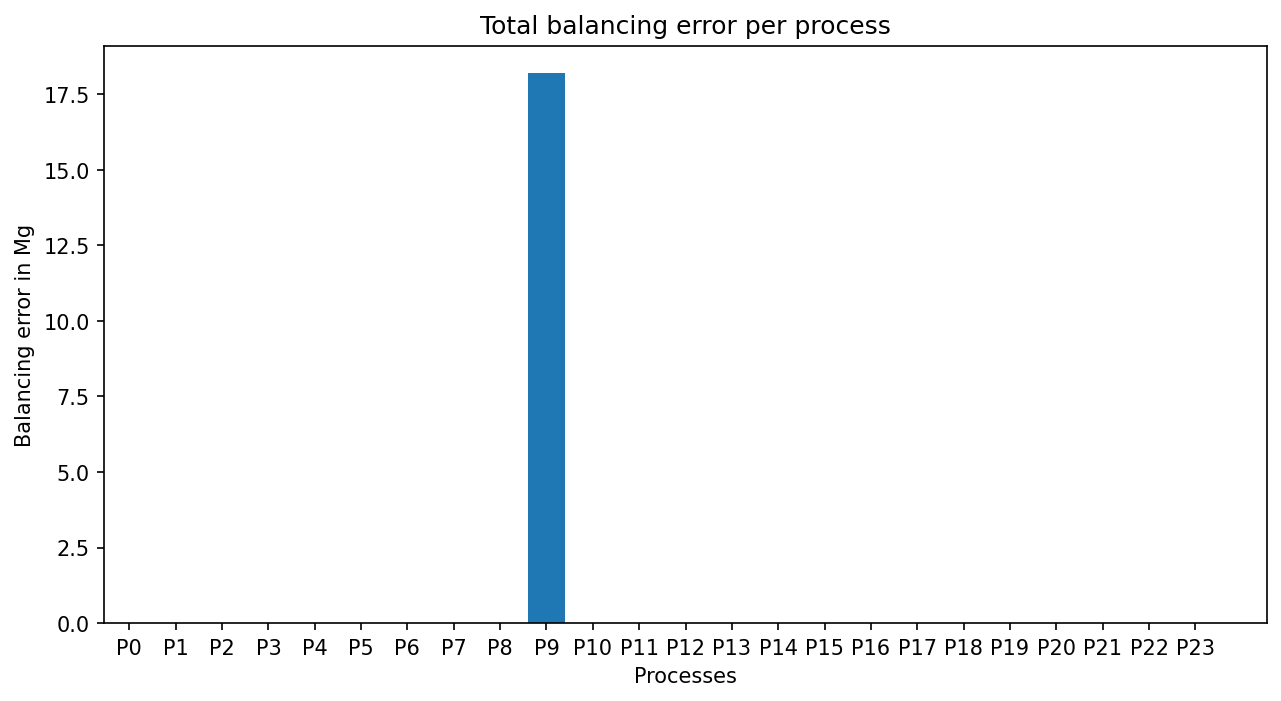

In [26]:
### Plot balancing error ###

# Create empty process list
process_list_balance = []

# Add process ID to list for plotting
for process in Dyn_MFA_System.ProcessList:
    process_list_balance.append(f"P{process.ID}")


# Enhance plot quality
plt.rcParams['figure.dpi'] = 150
# Create plot
plt.figure(figsize = (10, 5))
# Add bars to plot for each process
plt.bar(process_list_balance, balance_summary)

# Set labels, title and show plot
plt.xlabel('Processes')
plt.ylabel('Balancing error in Mg')
plt.title('Total balancing error per process')
plt.tight_layout
plt.show()

### 3.1.5 Final results

In [27]:
### Print all flows and stocks results ###

for flow in Dyn_MFA_System.FlowDict.values():
    print(flow.Name)
    print(flow.Values)

for stock in Dyn_MFA_System.StockDict.values():
    print(stock.Name)
    print(stock.Values)

F_13_20
[[1203277.89473684  168458.90526316 1034818.98947368  496713.11494737]
 [1014115.78947368  141976.21052632  872139.57894737  418626.99789474]
 [1248254.73684211  174755.66315789 1073499.07368421  515279.55536842]
 [1509023.15789474  211263.24210526 1297759.91578947  622924.75957895]
 [ 985555.78947368  137977.81052632  847577.97894737  406837.42989474]
 [ 985555.78947368  137977.81052632  847577.97894737  406837.42989474]
 [1525749.47368421  213604.92631579 1312144.54736842  629829.38273684]
 [1283917.89473684  179748.50526316 1104169.38947368  530001.30694737]
 [ 915452.63157895  128163.36842105  787289.26315789  377898.84631579]
 [1216938.94736842  170371.45263158 1046567.49473684  502352.39747368]
 [ 917250.52631579  128415.07368421  788835.45263158  378641.01726316]
 [ 916557.89473684  128318.10526316  788239.78947368  378355.09894737]
 [1127383.15789474  157833.64210526  969549.51578947  465383.76757895]
 [ 485343.15789474   67948.04210526  417395.11578947  200349.65557895

## 4 Presentation of results

There are several presentation options shown here. Simple plotting is possible, but interactive sankey diagrams and stock plots are also provided. Finally, results can be exported to Excel, also.

### 4.1 Simple plot soil

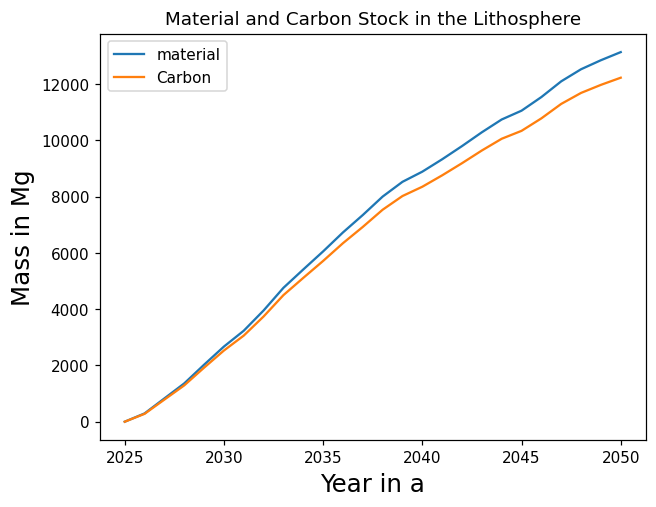

In [28]:
### Simple plotting ###


# Enhance plot quality
plt.rcParams['figure.dpi'] = 110


# Create empty plot
fig, ax = plt.subplots()
# Plotting time on x axis and soil stock on y, element index 0 so total material
ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.StockDict['S_17'].Values[:,0])
# Plotting time on x axis and soil stock change on y, element index 3 so carbon
ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.StockDict['S_17'].Values[:,3])

# Add y axis label
ax.set_ylabel('Mass in Mg',fontsize = 16)
# Add x axis label
ax.set_xlabel('Year in a',fontsize = 16)
# Add title
ax.set_title("Material and Carbon Stock in the Lithosphere")
# Add legend
ax.legend(['material', 'Carbon'])
# Modify x axis to show five years steps
ax.xaxis.set_major_locator(MultipleLocator(5))

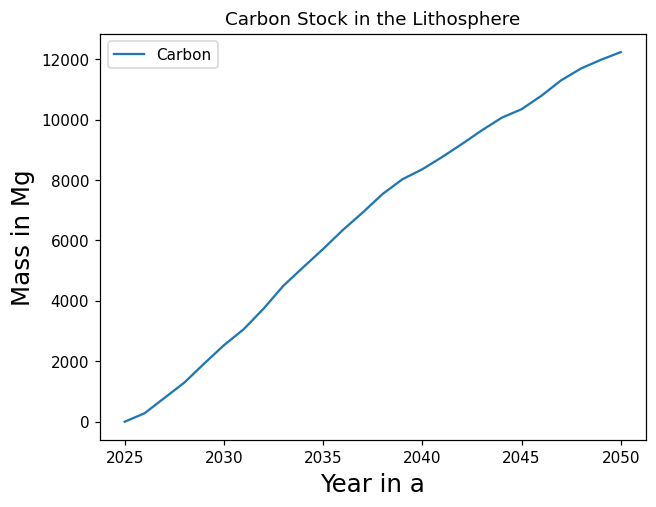

In [42]:
### Simple plotting ###


# Enhance plot quality
plt.rcParams['figure.dpi'] = 110


# Create empty plot
fig, ax = plt.subplots()
# Plotting time on x axis and soil stock change on y, element index 3 so carbon
ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.StockDict['S_17'].Values[:,3])

# Add y axis label
ax.set_ylabel('Mass in Mg',fontsize = 16)
# Add x axis label
ax.set_xlabel('Year in a',fontsize = 16)
# Add title
ax.set_title("Carbon Stock in the Lithosphere")
# Add legend
ax.legend(['Carbon'])
# Modify x axis to show five years steps
ax.xaxis.set_major_locator(MultipleLocator(5))

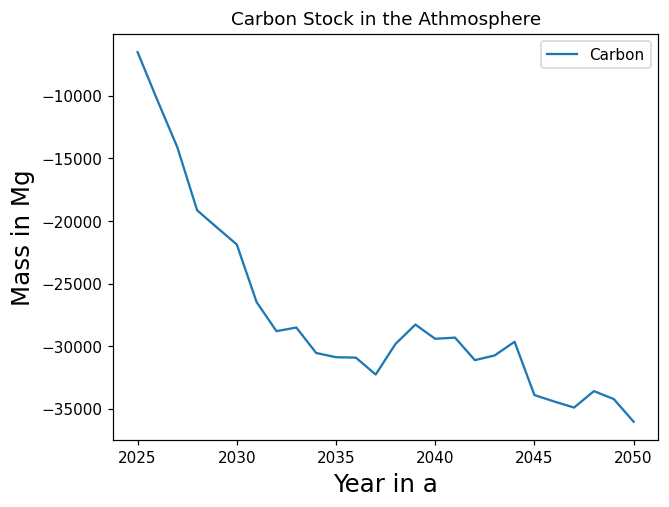

In [29]:
### Simple plotting ###


# Enhance plot quality
plt.rcParams['figure.dpi'] = 110


# Create empty plot
fig, ax = plt.subplots()
# Plotting time on x axis and soil stock on y, element index 0 so total material
#ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
#        Dyn_MFA_System.StockDict['S_19'].Values[:,0])
# Plotting time on x axis and soil stock change on y, element index 3 so carbon
ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.StockDict['S_19'].Values[:,3])

# Add y axis label
ax.set_ylabel('Mass in Mg',fontsize = 16)
# Add x axis label
ax.set_xlabel('Year in a',fontsize = 16)
# Add title
ax.set_title("Carbon Stock in the Athmosphere")
# Add legend
ax.legend(['Carbon'])
# Modify x axis to show five years steps
ax.xaxis.set_major_locator(MultipleLocator(5))


### 4.2 Interactive Sankey diagram

In [30]:
### Interactive Sankey color choice ###


# Here, the data of the ODYM MFA system is extracted and put into an applicable form for the interactive Sankey diagram 

# Choose colors for flows
# Create empty list
colors_flows = []
# Add colors to list in according to flow order in FlowDict
colors_flows.extend(["khaki" for i in range(6)])
colors_flows.extend(["mediumseagreen" for i in range(6)])
colors_flows.extend(["mediumpurple" for i in range(1)])
colors_flows.extend(["sandybrown" for i in range(3)])
colors_flows.extend(["mediumseagreen" for i in range(1)])
colors_flows.extend(["khaki" for i in range(1)])
colors_flows.extend(["skyblue" for i in range(2)])
colors_flows.extend(["mediumseagreen" for i in range(1)])
colors_flows.extend(["mediumpurple" for i in range(5)])
colors_flows.extend(["lightgray" for i in range(4)])
colors_flows.extend(["mediumpurple" for i in range(1)])

# Choose colors for processes
colors_processes = []
# All processes have color lightgray in this case
colors_processes.extend(["black" for i in range(24)])


In [31]:
### Interactive Sankey ###


# If diagram does not show, try enableling the widgetsnbextension 
# by running: jupyter nbextension enable --py --sys-prefix widgetsnbextension

# You can exclude certain flows by setting them here
# If you want to show all flows but an empty set like this: excluded_flows = {''}
excluded_flows = {}


# Biogas Production {'F_13_20', 'F_20_15', 'F_20_16', 'F_02_03', 'F_03_07', 'F_02_06', 'F_11_02', 'F_08_02', 'F_02_14', 'F_02_12', 'F_07_09', 'F_07_10', 'F_09_17', 'F_10_18', 'F_10_19', 'F_00_13', 'F_00_04', 'F_00_11', 'F_00_08', 'F_09_19', 'F_17_19', 'F_09_14', 'F_10_14'}
# MBC Production {'F_13_20', 'F_20_15', 'F_20_01', 'F_20_16', 'F_04_01', 'F_01_05', 'F_03_07', 'F_07_09', 'F_07_10', 'F_09_17', 'F_10_18', 'F_10_19', 'F_00_13', 'F_00_04', 'F_00_11', 'F_00_08', 'F_09_19', 'F_17_19', 'F_09_14', 'F_10_14', 'F_01_21'}




    #F_09_17', 'F_10_18', 'F_10_19', 'F_07_10', 'F_01_05', 'F_03_07', 'F_02_12', 'F_09_17',  'F_07_10', 'F_07_09', 'F_09_19', 'F_01_21'}
#F_00_13', 'F_00_04', 'F_00_11', 'F_00_08'

#'F_13_20',

#'F_20_15',
#'F_20_01',
#'F_20_16',
#'F_04_01',
#'F_01_05',
#'F_01_02',
#'F_02_03',
#'F_03_07',
#'F_02_06',
#'F_11_02',
#'F_08_02',
#'F_02_14',
#'F_02_12',
#'F_07_09',
#'F_07_10',
#'F_09_17',
#'F_10_18',
#'F_10_19',
#'F_00_13',
#'F_00_04',
#'F_00_11',
#'F_00_08',
#'F_09_19',
#'F_17_19',
#'F_09_14',
#'F_10_14',
#'F_01_21',
#'F_19_13',
#'F_19_04',
#'F_19_11',
#'F_15_19',
#'F_16_19'}



##F_13_20	Rye-Plant
#F_20_15	Rye-Grain
#F_20_01	Rye-Straw (technical usable)
#F_20_16	Rye-Straw (non-technical usable)
#F_04_01	Cow-Manure
#F_01_05	Biogas
#F_01_02	Rye-Straw-Digestate
#F_02_03	MBC-Product
#F_03_07	MBC-EoL
#F_02_06	MBC-Production waste
#F_11_02	Millet-Grain
#F_08_02	Water-Import
#F_02_14	Water-Export
#F_02_12	MBC-Production-Delta
#F_07_09	MBC (EoL)-Pyrolysis
#F_07_10	MBC (EoL)-Incineration
#F_09_17	Biochar-Pyrolysis
#F_10_18	Ash-Incineration
#F_10_19	Flue Gas-Incineration
#F_00_13	Environment-Rye
#F_00_04	Environment-Cow-Manure
#F_00_11	Environment-Millet
#F_00_08	Environment-Water
#F_09_19	Flue Gas-Pyrolysis
#F_17_19	CO2-from Lithosphere
#F_09_14	Water-Pyrolysis
#F_10_14	Water-Incineration
#F_01_21	Biogas-Production-Delta
#F_19_13	CO2-to Rye_Cultivation
#F_19_04	CO2-to Cow-Manure_Production
#F_19_11	CO2-to Millet_Production
#F_15_19	CO2-from Rye-Grain_Processing & Consumption
#F_16_19	CO2-from Rye-Straw (non-mobilizable)_Degradation



# Apply bioDYM function to create Sankey
bipl.sankey_results(Dyn_MFA_System, MyYears, ModelClassification, colors_flows, colors_processes, excluded_flows)

FigureWidget({
    'data': [{'link': {'color': [khaki, khaki, khaki, khaki, khaki, khaki,
                                 mediumseagreen, mediumseagreen, mediumseagreen,
                                 mediumseagreen, mediumseagreen, mediumseagreen,
                                 mediumpurple, sandybrown, sandybrown, sandybrown,
                                 mediumseagreen, khaki, skyblue, skyblue,
                                 mediumseagreen, mediumpurple, mediumpurple,
                                 mediumpurple, mediumpurple, mediumpurple,
                                 lightgray, lightgray, lightgray, lightgray,
                                 mediumpurple],
                       'source': [13, 20, 20, 20, 4, 1, 1, 2, 3, 2, 11, 8, 2, 2,
                                  7, 7, 9, 10, 10, 0, 0, 0, 0, 9, 17, 9, 1, 19, 19,
                                  19, 15, 16, 5, 15, 16, 12, 12, 6, 6, 21, 21, 14,
                                  5, 20, 23, 23, 22],
            

interactive(children=(Dropdown(description='element:', options=('material', 'WC', 'DM', 'CC'), value='material…

### 4.3 Interactive stock plots

In [32]:
### Interactive stock plot ###


# Apply bioDYM function
bipl.bar_stocks_results(Dyn_MFA_System, MyYears, ModelClassification, colors_processes)

FigureWidget({
    'data': [{'marker': {'color': ['black', 'black', 'black']},
              'type': 'bar',
              'uid': 'f3f7e44f-6757-4abb-b435-38a23aed349c',
              'x': [MBC_Use-Phase, Lithosphere_Stock, Atmosphere_Stock],
              'y': [41795.009174283274, 25432.263082551373, 16362.746091731902,
                    6512.372944509297]}],
    'layout': {'template': '...', 'title': {'text': 'System stocks diagram material (years 2025-2050) [t]'}}
})

interactive(children=(Dropdown(description='element:', options=('material', 'WC', 'DM', 'CC'), value='material…

### 4.5 MBC dynamic stock model

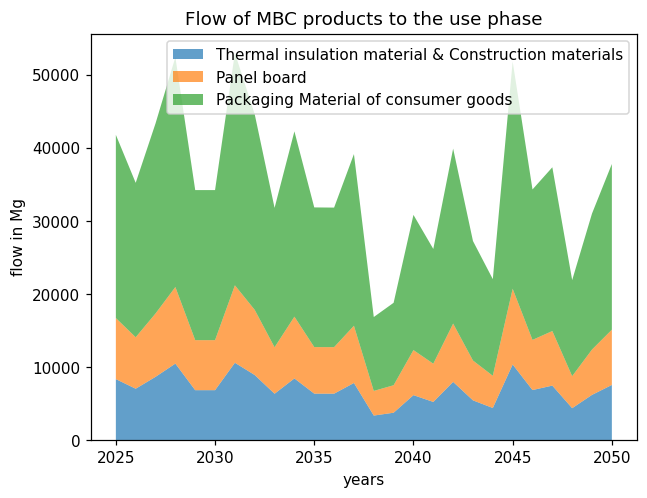

In [37]:
### Plot MBC products to use phase as stackplot ###


plt.stackplot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, MBC_Dict['F_02_03_MBCs'].Values[:, 0], MBC_Dict['F_02_03_MBCs'].Values[:, 1], MBC_Dict['F_02_03_MBCs'].Values[:, 2], labels = ['Thermal insulation material & Construction materials', 'Panel board', 'Packaging Material of consumer goods '], alpha = 0.7)
# Labels and title
plt.xlabel('years')
plt.ylabel('flow in Mg')
plt.title('Flow of MBC products to the use phase')
plt.legend()

# Show plot
plt.show()

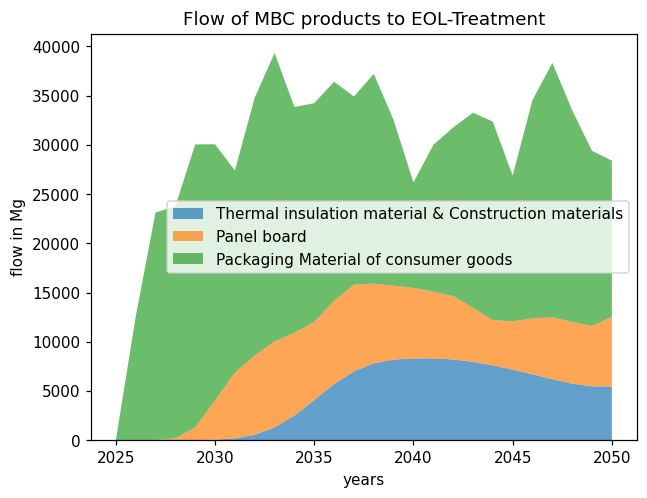

In [38]:
### Plot MBC products to EOL-Treatment ###


plt.stackplot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, MBC_Dict['F_03_07_MBCs'].Values[:, 0], MBC_Dict['F_03_07_MBCs'].Values[:, 1], MBC_Dict['F_03_07_MBCs'].Values[:, 2], labels = ['Thermal insulation material & Construction materials', 'Panel board', 'Packaging Material of consumer goods'], alpha = 0.7)
# Labels and title
plt.xlabel('years')
plt.ylabel('flow in Mg')
plt.title('Flow of MBC products to EOL-Treatment')
plt.legend()

# Show plot
plt.show()

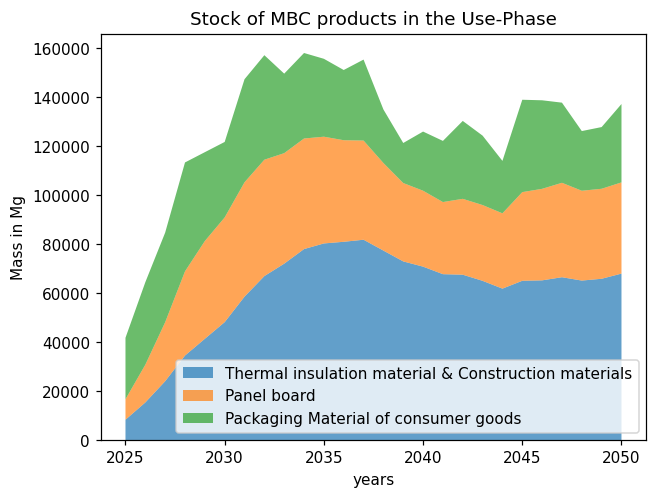

In [44]:
### Plot MBC products stock in use phase ###


plt.stackplot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, MBC_Dict['S_3_MBCs'].Values[:, 0],MBC_Dict['S_3_MBCs'].Values[:, 1], MBC_Dict['S_3_MBCs'].Values[:, 2], labels = ['Thermal insulation material & Construction materials', 'Panel board', 'Packaging Material of consumer goods '], alpha = 0.7)
# Labels and title
plt.xlabel('years')
plt.ylabel('Mass in Mg')
plt.title('Stock of MBC products in the Use-Phase')
plt.legend()

# Show plot
plt.show()

### 4.6 Excel export

In [36]:
### Excel export ###


# Apply bioDYM function to export all flows and stocks on all element levels
bix.export_xlsx(Dyn_MFA_System, MyYears, ModelClassification)